### Setup
Load necessary libraries for data processing and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### Data Loading
Import the dataset to start the analysis.

In [4]:
df = pd.read_csv("Aleks Calculus DF.csv")
df

,Calculus Grade,SHS,Initial Algebra and Geometry Review,Initial Graphs and Functions,Initial Polynomial and Rational Functions,Initial Exponential and Logarithmic Functions,Initial Trigonometric Identities and Equations,Initial Systems of Equations and Matrices,Initial Conic Sections,Weighted Initial Grade,Post Algebra and Geometry Review,Post Graphs and Functions,Post Polynomial and Rational Functions,Post Exponential and Logarithmic Functions,Post Trigonometric Identities and Equations,Post Systems of Equations and Matrices,Post Conic Sections,Weighted Latest Grade,Net Algebra and Geometry Review,Net Graphs and Functions,Net Polynomial and Rational Functions,Net Exponential and Logarithmic Functions,Net Trigonometric Identities and Equations,Net Systems of Equations and Matrices,Net Conic Sections
0,5.00,0,0.42,0.10,0.00,0.00,0.00,0.00,0.00,0.05,0.42,0.10,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,3.00,0,0.77,0.25,0.13,0.27,0.00,0.12,0.21,0.21,0.84,0.59,0.63,0.82,0.29,0.12,0.32,0.47,0.07,0.34,0.50,0.55,0.29,0.00,0.11
2,5.00,0,0.88,0.67,0.19,0.91,0.36,0.18,0.26,0.41,0.93,0.98,0.69,1.00,0.71,0.65,0.58,0.75,0.05,0.31,0.50,0.09,0.35,0.47,0.32
3,5.00,0,0.49,0.04,0.00,0.09,0.00,0.00,0.00,0.06,0.71,0.69,0.69,0.55,0.50,0.06,0.00,0.42,0.22,0.65,0.69,0.46,0.50,0.06,0.00
4,5.00,0,0.96,0.78,0.38,0.91,0.64,0.41,0.74,0.63,0.96,1.00,1.00,1.00,0.79,0.71,0.84,0.88,0.00,0.22,0.62,0.09,0.15,0.30,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1983,3.00,0,0.20,0.10,0.00,0.00,0.00,0.00,0.00,0.03,0.75,0.61,0.44,0.82,0.43,0.06,0.11,0.40,0.55,0.51,0.44,0.82,0.43,0.06,0.11
1984,3.00,0,0.61,0.06,0.00,0.18,0.00,0.00,0.05,0.09,0.71,0.86,0.63,0.91,0.57,0.00,0.16,0.48,0.10,0.80,0.63,0.73,0.57,0.00,0.11
1985,2.25,0,0.55,0.20,0.00,0.27,0.00,0.00,0.21,0.13,0.81,0.84,0.75,1.00,0.57,0.00,0.63,0.60,0.26,0.64,0.75,0.73,0.57,0.00,0.42
1986,3.00,0,0.22,0.16,0.00,0.00,0.00,0.00,0.00,0.04,0.78,0.67,0.56,0.91,0.71,0.24,0.58,0.59,0.56,0.51,0.56,0.91,0.71,0.24,0.58


## 1. Data Cleaning and Preparation

### 1A. Check for duplicates
Remove duplicate student records to ensure each observation is unique, preventing bias in the analysis and model training.

In [5]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been removed.")
    print(f"New shape of the DataFrame: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 37
Duplicate rows have been removed.
New shape of the DataFrame: (1951, 25)


### 1B. Check for Missing Values
Explanation: Impute missing values in all numerical columns with the mean of that column. This completes the dataset, allowing the model to process all features.

In [6]:
print("\n--- Missing Values Before Imputation ---")
print(df.isnull().sum())

numerical_cols = df.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].mean(), inplace=True)

print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum().max())


--- Missing Values Before Imputation ---
Calculus Grade                                    0
SHS                                               0
Initial Algebra and Geometry Review               0
Initial Graphs and Functions                      0
Initial Polynomial and Rational Functions         0
Initial Exponential and Logarithmic Functions     0
Initial Trigonometric Identities and Equations    0
Initial Systems of Equations and Matrices         0
Initial Conic Sections                            0
Weighted Initial Grade                            0
Post Algebra and Geometry Review                  0
Post Graphs and Functions                         0
Post Polynomial and Rational Functions            0
Post Exponential and Logarithmic Functions        0
Post Trigonometric Identities and Equations       0
Post Systems of Equations and Matrices            0
Post Conic Sections                               0
Weighted Latest Grade                             0
Net Algebra and Geomet

### 1C. Check for the Datatype Format
Explanation: Verify data types to ensure numerical columns are correctly identified, which is crucial for scaling and model input.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1951 entries, 0 to 1987
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Calculus Grade                                  1951 non-null   float64
 1   SHS                                             1951 non-null   int64  
 2   Initial Algebra and Geometry Review             1951 non-null   float64
 3   Initial Graphs and Functions                    1951 non-null   float64
 4   Initial Polynomial and Rational Functions       1951 non-null   float64
 5   Initial Exponential and Logarithmic Functions   1951 non-null   float64
 6   Initial Trigonometric Identities and Equations  1951 non-null   float64
 7   Initial Systems of Equations and Matrices       1951 non-null   float64
 8   Initial Conic Sections                          1951 non-null   float64
 9   Weighted Initial Grade                        

### 1D. Check Inconsistencies
Explanation: Check the unique values in the Calculus Grade (the 10 numerical classes) and the categorical SHS column to confirm all values are standardized before encoding.

In [16]:
print("\n'Calculus Grade' unique values:")
print(df['Calculus Grade'].value_counts())

print("\n'SHS' unique values:")
print(df['SHS'].value_counts())


'Calculus Grade' unique values:
Calculus Grade
5.00    1053
3.00     404
2.50     106
2.75      90
1.75      71
2.25      61
2.00      52
1.25      42
1.00      39
1.50      33
Name: count, dtype: int64

'SHS' unique values:
SHS
0    1610
1     341
Name: count, dtype: int64


## Exploratory Data Analysis (EDA)

### 2A. Plot the data (univariate/bivariate)
Use box plots to visually compare the distribution of initial mastery, final mastery, and net gain against the final score.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


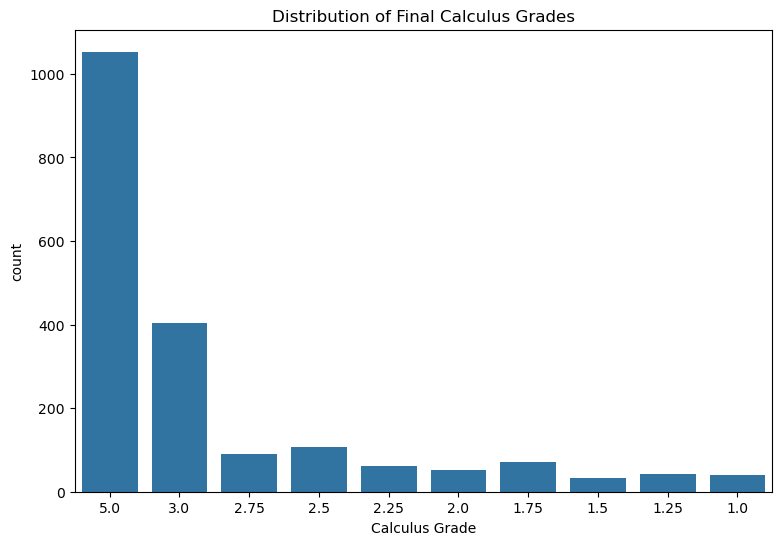

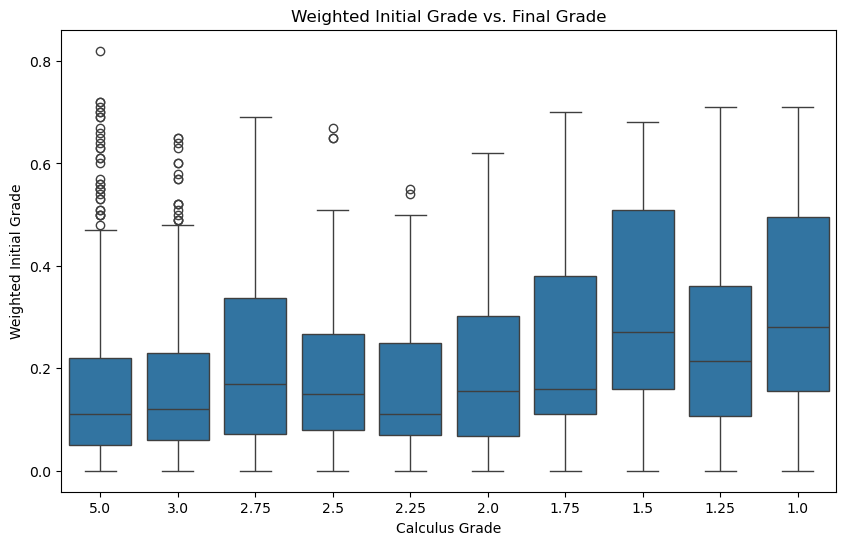

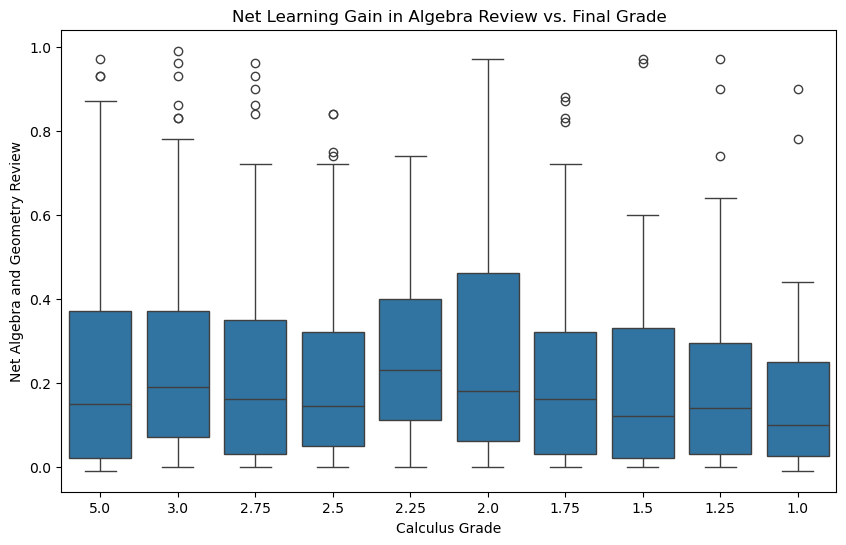

In [18]:
Tgt = 'Calculus Grade'
grade_order = sorted([float(c) for c in df[Tgt].unique()], reverse=True)

plt.figure(figsize=(9, 6))
sns.countplot(x=Tgt, data=df, order=grade_order)
plt.title('Distribution of Final Calculus Grades')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=Tgt, y='Weighted Initial Grade', data=df, order=grade_order)
plt.title('Weighted Initial Grade vs. Final Grade')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x=Tgt, y='Net Algebra and Geometry Review', data=df, order=grade_order)
plt.title('Net Learning Gain in Algebra Review vs. Final Grade')
plt.show()

### 2B. Check for relationships (correlation plot)
Plot the relationship between the two most predictive features (Post Algebra Review and Weighted Latest Grade) to visually confirm their strong correlation and identify potential outliers.

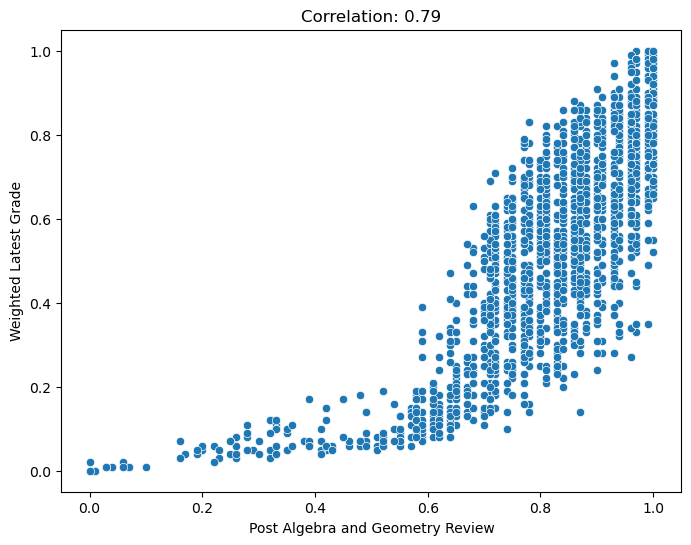

In [20]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numerical_cols].corr()
correlation_value = correlation_matrix.loc['Post Algebra and Geometry Review', 'Weighted Latest Grade']

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Post Algebra and Geometry Review', y='Weighted Latest Grade', data=df)
plt.title(f"Correlation: {correlation_value:.2f}")
plt.show()

### 2C. STORY

The Exploratory Data Analysis (EDA) reveals that student success in Calculus is primarily determined by final mastery metrics, while initial preparedness plays a negligible role in separating top performers.

1. **The Grade Distribution is Highly Skewed**

The Distribution of Final Calculus Grades shows a heavily skewed and bimodal pattern.

* *The majority of students achieved the worst possible grade* (score of 5.0), followed by a significant cluster at the mid-level grade of 3.0.

* *Only a small fraction of students achieved the top grades* (1.0, 1.25, 1.5). This indicates that the largest cohort of students either struggled significantly or passed at a moderate level, while true mastery (the 1.0 grade) was rare.

2. **Initial Knowledge is Not a Key Separator**

The Weighted Initial Grade vs. Final Grade box plot shows that high initial scores (top quartile) exist across all final grades (1.0 through 5.0).

* *Initial knowledge does not guarantee success:* The plot shows that students who ultimately earned the worst grade (5.0) had the same median initial knowledge as students who earned the best grade (1.0).

* *The median initial grade is low (near 0.2 or lower)* and similar across almost all final scores, confirming that most students started with low overall preparedness regardless of their final outcome.

3. **Learning Gain Correlates with Mid-Range Performance**

The Net Learning Gain in Algebra Review vs. Final Grade box plot shows that raw learning gain is highest for students receiving poor-to-mid-range scores (like 2.0 to 3.0).

* *Top Performers (1.0s) have lower median Net Gain.* This is expected: students who earned the best grades likely started with higher implicit knowledge and had less room for massive "Net Gain."

* The plot indicates that achieving a *large net gain primarily helps struggling students* (the 5.0 cohort) move up to a passing grade (3.0), but it is not the defining characteristic of an A-level performance (1.0).

4. **Final Mastery is the Overwhelming Predictor**

The scatter plot showing the relationship between Post Algebra and Geometry Review and Weighted Latest Grade reveals the critical insight:

* *Strong Positive Correlation:* The correlation coefficient of $\mathbf{r=0.79}$ confirms a strong, positive, linear relationship.

* *Predictive Power:* Students who scored high on a key Post module are virtually guaranteed to have a high Weighted Latest Grade (near 1.0). This cluster of high scores is extremely tight, demonstrating that final mastery level is the dominant factor determining overall student success—and the clearest differentiator for the predictive model.

## 3. Preprocessing and Model Setup

### 3a. Scale/Encode Data and Define Target
Separate features (X) from the target (y). Label Encode the 10 numerical grades. Standardize all numerical data to ensure all scores contribute equally, and One-Hot Encode the categorical SHS feature.

In [10]:
TARGET_VARIABLE = 'Calculus Grade' 
X = df.drop(TARGET_VARIABLE, axis=1) 
y = df[TARGET_VARIABLE]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target classes found: {le.classes_}")

numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_nominal_features = ['SHS']

preprocessor = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_nominal_features)
    ],
    remainder='drop' 
)

X_processed = preprocessor.fit_transform(X)

Target classes found: [1.   1.25 1.5  1.75 2.   2.25 2.5  2.75 3.   5.  ]


### 3B. Split the entire data to 70:30 ratio
Divide the processed data into a 70% training set (for the model to learn) and a 30% test set (for unbiased performance evaluation).

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.30, 
    random_state=42, 
    stratify=y_encoded
)

print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

Train samples: 1365 | Test samples: 586


### 3c. Train the data on 70 and validate on the remaining 30%
Initialize and train the Random Forest Classifier model on the training data (X_train, y_train) and generate predictions (y_pred) on the test data.

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### 3D. Evaluation
Measure the model's predictive power using Accuracy, the Confusion Matrix (to see errors per score), and the Classification Report (detailed metrics for each of the 10 grade categories).

In [13]:
target_names_str = [str(c) for c in le.classes_]

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true=y_test, 
    y_pred=y_pred, 
    target_names=target_names_str,
    zero_division=0
))

Accuracy Score: 0.5205

Confusion Matrix:
[[  1   0   0   1   1   0   0   0   5   4]
 [  1   1   1   0   0   0   0   0   3   7]
 [  1   0   0   0   1   0   0   0   3   5]
 [  0   1   1   1   0   0   0   0  11   7]
 [  0   0   0   0   0   0   0   0   5  11]
 [  0   0   0   0   0   0   1   1   6  10]
 [  1   0   0   0   0   0   0   0   5  26]
 [  0   0   0   2   0   3   1   1   1  19]
 [  0   0   1   2   0   1   1   0  23  93]
 [  1   1   1   2   0   0   0   1  32 278]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.20      0.08      0.12        12
        1.25       0.33      0.08      0.12        13
         1.5       0.00      0.00      0.00        10
        1.75       0.12      0.05      0.07        21
         2.0       0.00      0.00      0.00        16
        2.25       0.00      0.00      0.00        18
         2.5       0.00      0.00      0.00        32
        2.75       0.33      0.04      0.07        27
         3.0    